In [1]:
import numpy as np
import pandas as pd

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Timestamp Object

- 'Timestamp' to store a particular moment in time ( e.g. Oct 24th, 2022 at 7:00 pm )

## Creating Timestamp Object

In [2]:
pd.Timestamp('2025/12/12')

Timestamp('2025-12-12 00:00:00')

In [3]:
# variations
pd.Timestamp('2025-12-12')
pd.Timestamp('2025,12,12')

# only year
pd.Timestamp('2025')       # consider 1st-month and 1st-day of the given year

Timestamp('2025-01-01 00:00:00')

In [4]:
# using textual interpretation
pd.Timestamp('12th Dec 2025')

Timestamp('2025-12-12 00:00:00')

In [5]:
# providing time now with 'AM/PM'
pd.Timestamp('12th Dec 2025 4:24 AM')

Timestamp('2025-12-12 04:24:00')

## using 'datetime.datetime' python's object

In [6]:
import datetime as dt

dt.datetime(2025,12,12,4,25)

datetime.datetime(2025, 12, 12, 4, 25)

In [7]:
# creating 'Timestamp' object with 'datetime' object
import datetime as dt

x = pd.Timestamp(dt.datetime(2025,12,12,4,25))    # storing 'Timestamp' object as 'x'
x

Timestamp('2025-12-12 04:25:00')

In [8]:
# fetching attributes of Timestamp object
x.year
x.month
x.day
x.hour
x.minute
x.second

0

## Why separate objects to handle 'date and time' when python already has in-built 'datetime' object functionality

- syntax wise 'datetime' is very convenient
- But the performance wise it's slow while wokring with huge data
- The weaknesses of python's 'datetime' format inspired the NumPy team to add a set of native time series data type to NumPy ( datetime64 )
- The 'datetime64' encode dates as 64-bit integers, and thus allows arrays of dates to be represented very compactly

In [9]:
import numpy as np
date = np.array('2025-12-12' , dtype = np.datetime64)
date

array('2025-12-12', dtype='datetime64[D]')

In [10]:
# vectorized operations on this 'datetime64' object
date + np.arange(10)            # now 10 continuous date-times are available

array(['2025-12-12', '2025-12-13', '2025-12-14', '2025-12-15',
       '2025-12-16', '2025-12-17', '2025-12-18', '2025-12-19',
       '2025-12-20', '2025-12-21'], dtype='datetime64[D]')

- Because of uniform type in NumPy 'datetime64' arrays, this type of operation can be accomplished much more quickly than if we were working with Python's 'datetime' object, especially when large data will be there

- Pandas 'Timestamp' object combines the ease-of-use of 'python datetime' with the efficient storage and vectorized interface of 'numpy datetime64 object'

- From a group of these 'Timestamp' objects, Pandas can construct a 'DatetimeIndex' that can be used to index data in a Series or DataFrame

DatetimeIndex Object
- A collection of Pandas Timestamp objects

In [11]:
# from strings
time = pd.DatetimeIndex(['2025/1/1' , '2024/1/1' , '2023/1/1'])      # list of date-format strings inside 'DatetimeIndex'
time

DatetimeIndex(['2025-01-01', '2024-01-01', '2023-01-01'], dtype='datetime64[ns]', freq=None)

In [12]:
# fetching single date
time[0]                   # single date is a Timestamp object

Timestamp('2025-01-01 00:00:00')

In [13]:
# using python datetime object
pd.DatetimeIndex([dt.datetime(2025,1,1) , dt.datetime(2024,1,1) , dt.datetime(2023,1,1)])

DatetimeIndex(['2025-01-01', '2024-01-01', '2023-01-01'], dtype='datetime64[ns]', freq=None)

In [14]:
# using pd.Timestamp
dt_index = pd.DatetimeIndex([pd.Timestamp(2025,1,1) , pd.Timestamp(2024,1,1) , pd.Timestamp(2023,1,1)])
dt_index

DatetimeIndex(['2025-01-01', '2024-01-01', '2023-01-01'], dtype='datetime64[ns]', freq=None)

In [15]:
# 'DatetimeIndex' as 'Series' index
pd.Series([1 , 2 , 3] , index = dt_index)

,0
2025-01-01,1
2024-01-01,2
2023-01-01,3


### date_range() function
- generates daily dates in a given range

In [16]:
# continuous dates
pd.date_range(start = '2025-1-1' , end = '2025-2-1' , freq = 'D')      # 'yyyy-mm-dd' format


# freq = '2D' -> alternate dates
pd.date_range(start = '2025-1-1' , end = '2025-2-1' , freq = '2D')     # just change -> freq = '2D'


# freq = '3D' -> gap of 2 dates
pd.date_range(start = '2025-1-1' , end = '2025-2-1' , freq = '3D')     # freq = '3D'

DatetimeIndex(['2025-01-01', '2025-01-04', '2025-01-07', '2025-01-10',
               '2025-01-13', '2025-01-16', '2025-01-19', '2025-01-22',
               '2025-01-25', '2025-01-28', '2025-01-31'],
              dtype='datetime64[ns]', freq='3D')

In [17]:
# freq = 'B' -> Business days hi aayenge sirf means monday to friday wali dates will be there and sat-sun wali dates will be ignored
pd.date_range(start = '2025-1-1' , end = '2025-2-1' , freq = 'B')

DatetimeIndex(['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-06',
               '2025-01-07', '2025-01-08', '2025-01-09', '2025-01-10',
               '2025-01-13', '2025-01-14', '2025-01-15', '2025-01-16',
               '2025-01-17', '2025-01-20', '2025-01-21', '2025-01-22',
               '2025-01-23', '2025-01-24', '2025-01-27', '2025-01-28',
               '2025-01-29', '2025-01-30', '2025-01-31'],
              dtype='datetime64[ns]', freq='B')

In [18]:
# freq = 'W-day' -> dates of given day(mon, tue, thu, fri, sat, sun) per week
pd.date_range(start = '2025-1-1' , end = '2025-2-1' , freq = 'W-MON')

DatetimeIndex(['2025-01-06', '2025-01-13', '2025-01-20', '2025-01-27'], dtype='datetime64[ns]', freq='W-MON')

In [19]:
# freq = 'H' -> hourly timestamps ( H, 2H , 3H , 4H , 5H , ...... , 24H)
pd.date_range(start = '2025-1-1' , end = '2025-1-2' , freq = 'h')

DatetimeIndex(['2025-01-01 00:00:00', '2025-01-01 01:00:00',
               '2025-01-01 02:00:00', '2025-01-01 03:00:00',
               '2025-01-01 04:00:00', '2025-01-01 05:00:00',
               '2025-01-01 06:00:00', '2025-01-01 07:00:00',
               '2025-01-01 08:00:00', '2025-01-01 09:00:00',
               '2025-01-01 10:00:00', '2025-01-01 11:00:00',
               '2025-01-01 12:00:00', '2025-01-01 13:00:00',
               '2025-01-01 14:00:00', '2025-01-01 15:00:00',
               '2025-01-01 16:00:00', '2025-01-01 17:00:00',
               '2025-01-01 18:00:00', '2025-01-01 19:00:00',
               '2025-01-01 20:00:00', '2025-01-01 21:00:00',
               '2025-01-01 22:00:00', '2025-01-01 23:00:00',
               '2025-01-02 00:00:00'],
              dtype='datetime64[ns]', freq='h')

In [20]:
# freq = 'ME' -> month end from the given range
pd.date_range(start = '2025-1-1' , end = '2025-2-28' , freq = 'ME')     # gives '31-january' and '28-february'

# freq = 'MS' -> month start from the given range
pd.date_range(start = '2025-1-1' , end = '2025-2-1' , freq = 'MS')      # gives '1-january' and '1-february'

DatetimeIndex(['2025-01-01', '2025-02-01'], dtype='datetime64[ns]', freq='MS')

In [28]:
# freq = 'YE' -> year end date from the given range
pd.date_range(start = '2025-1-1' , end = '2030-12-31' , freq = 'YE')

# freq = 'YE-MON' -> year end date from specific month( JULY -> JUL )
pd.date_range(start = '2025-1-1' , end = '2030-12-31' , freq = 'YE-JUL')

DatetimeIndex(['2025-07-31', '2026-07-31', '2027-07-31', '2028-07-31',
               '2029-07-31', '2030-07-31'],
              dtype='datetime64[ns]', freq='YE-JUL')

In [22]:
# using 'periods' for number of results ( isme hum 'end' parameter nhi dete ) and freq = '' ko apne hisab se le sakte hai toh 'periods' fir vaise hi results dega
pd.date_range(start = '2025-1-1' , periods = 20 , freq = 'D')       # 20-days
pd.date_range(start = '2025-1-1' , periods = 20 , freq = 'YS')      # 20-years with start date of every year
pd.date_range(start = '2025-1-1' , periods = 20 , freq = 'h')       # 6-hours gap

DatetimeIndex(['2025-01-01 00:00:00', '2025-01-01 01:00:00',
               '2025-01-01 02:00:00', '2025-01-01 03:00:00',
               '2025-01-01 04:00:00', '2025-01-01 05:00:00',
               '2025-01-01 06:00:00', '2025-01-01 07:00:00',
               '2025-01-01 08:00:00', '2025-01-01 09:00:00',
               '2025-01-01 10:00:00', '2025-01-01 11:00:00',
               '2025-01-01 12:00:00', '2025-01-01 13:00:00',
               '2025-01-01 14:00:00', '2025-01-01 15:00:00',
               '2025-01-01 16:00:00', '2025-01-01 17:00:00',
               '2025-01-01 18:00:00', '2025-01-01 19:00:00'],
              dtype='datetime64[ns]', freq='h')

### to_datetime() function
- converts an existing object into Pandas 'Timestamp/DatetimeIndex' object

In [23]:
# from a 'Series' object

# making a series with list of string dates
s = pd.Series(['2025/1/1' , '2024/1/1' , '2023/1/1'])
display(s)


# converting into NumPy wala 'datetime64' object
d = pd.to_datetime(s)
d

,0
0,2025/1/1
1,2024/1/1
2,2023/1/1


,0
0,2025-01-01
1,2024-01-01
2,2023-01-01


In [24]:
# fetching data from 'datetime64' date using 'dt' accessor

# fetching 'day'
d.dt.day

# fetching 'months'
d.dt.month

# fetching 'year'
d.dt.year

# fetching 'day name'
d.dt.day_name()

# fetching 'month name'
d.dt.month_name()

,0
0,January
1,January
2,January


In [25]:
# with errors in dates

# making a Series with wrong syntax date
s = pd.Series(['2025/1/1' , '2024/1/1' , '2023/130/1'])
display(s)


# errors = 'coerce' -> ignores the wrong syntax date
pd.to_datetime(s , errors = 'coerce')                # error date will replaced as 'NaT' means 'Not a Time'

,0
0,2025/1/1
1,2024/1/1
2,2023/130/1


,0
0,2025-01-01
1,2024-01-01
2,NaT


## Working on real dataset on 'expense.csv'

- Question : find the mean expense of the person on different days

In [29]:
df = pd.read_csv('/content/drive/MyDrive/CSV_files/expense_data.csv')
df

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0
...,...,...,...,...,...,...,...,...,...,...,...
272,11/22/2021 14:16,CUB - online payment,Food,NaN,Dinner,90.0,Expense,NaN,90.0,INR,90.0
273,11/22/2021 14:16,CUB - online payment,Food,NaN,Lunch with company,97.0,Expense,NaN,97.0,INR,97.0
274,11/21/2021 17:07,CUB - online payment,Transportation,NaN,Rapido,130.0,Expense,NaN,130.0,INR,130.0
275,11/21/2021 15:50,CUB - online payment,Food,NaN,Lunch,875.0,Expense,NaN,875.0,INR,875.0


In [30]:
# convert 'Date' column from object -> datetime64
df['Date'] = pd.to_datetime(df['Date'])             # after converting we are storing changes in main dataset
df

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0
...,...,...,...,...,...,...,...,...,...,...,...
272,2021-11-22 14:16:00,CUB - online payment,Food,NaN,Dinner,90.0,Expense,NaN,90.0,INR,90.0
273,2021-11-22 14:16:00,CUB - online payment,Food,NaN,Lunch with company,97.0,Expense,NaN,97.0,INR,97.0
274,2021-11-21 17:07:00,CUB - online payment,Transportation,NaN,Rapido,130.0,Expense,NaN,130.0,INR,130.0
275,2021-11-21 15:50:00,CUB - online payment,Food,NaN,Lunch,875.0,Expense,NaN,875.0,INR,875.0


In [31]:
df.info()    # successfully converted to 'datetime64' object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            277 non-null    datetime64[ns]
 1   Account         277 non-null    object        
 2   Category        277 non-null    object        
 3   Subcategory     0 non-null      float64       
 4   Note            273 non-null    object        
 5   INR             277 non-null    float64       
 6   Income/Expense  277 non-null    object        
 7   Note.1          0 non-null      float64       
 8   Amount          277 non-null    float64       
 9   Currency        277 non-null    object        
 10  Account.1       277 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(5)
memory usage: 23.9+ KB


In [32]:
# day wise bar chart of spending

# first fetch day_names and add that column to main dataset
df['day_name'] = df['Date'].dt.day_name()
df

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,day_name
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,Wednesday
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,Wednesday
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,Tuesday
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,Tuesday
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...
272,2021-11-22 14:16:00,CUB - online payment,Food,NaN,Dinner,90.0,Expense,NaN,90.0,INR,90.0,Monday
273,2021-11-22 14:16:00,CUB - online payment,Food,NaN,Lunch with company,97.0,Expense,NaN,97.0,INR,97.0,Monday
274,2021-11-21 17:07:00,CUB - online payment,Transportation,NaN,Rapido,130.0,Expense,NaN,130.0,INR,130.0,Sunday
275,2021-11-21 15:50:00,CUB - online payment,Food,NaN,Lunch,875.0,Expense,NaN,875.0,INR,875.0,Sunday


,INR
day_name,
Friday,203.235294
Monday,156.223750
Saturday,649.453208
Sunday,955.830303
Thursday,208.054565
Tuesday,456.438158
Wednesday,234.559697


<Axes: xlabel='day_name', ylabel='INR'>

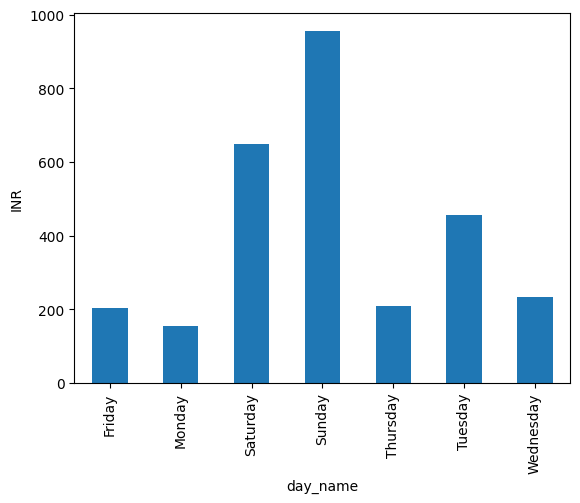

In [33]:
# groupby() karo 'day_name' column pe and then apply 'mean'
display(df.groupby('day_name')['INR'].mean())

# plot the bar chart now
df.groupby('day_name')['INR'].mean().plot(kind = 'bar' , ylabel = 'INR')